<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/Clothing_Image_Classifier_with_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train = X_train[:2000]
y_train = y_train[:2000]

X_test = X_test[:1000]
y_test = y_test[:1000]

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [6]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

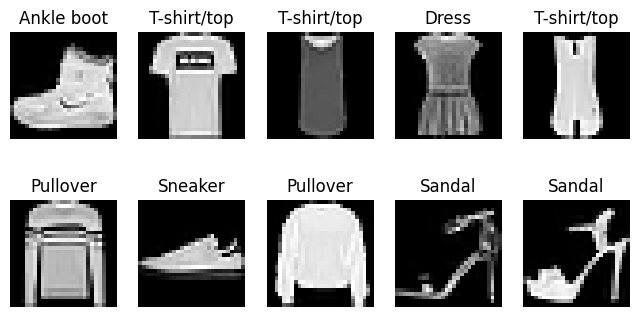

In [7]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

In [8]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

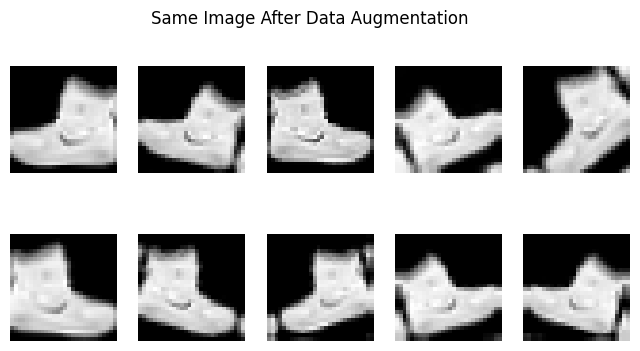

In [9]:
image = X_train[0:1]

plt.figure(figsize=(8, 4))

for i in range(10):
    augmented_image = data_augmentation(image, training=True)

    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_image[0].numpy().reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Same Image After Data Augmentation")
plt.show()

In [10]:
model_without_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model_without_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_without_aug = model_without_aug.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.5215 - loss: 1.3763 - val_accuracy: 0.6860 - val_loss: 0.8488
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7260 - loss: 0.7659 - val_accuracy: 0.7370 - val_loss: 0.6941
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7650 - loss: 0.6474 - val_accuracy: 0.7560 - val_loss: 0.6498
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7875 - loss: 0.6058 - val_accuracy: 0.7660 - val_loss: 0.5966
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8145 - loss: 0.5276 - val_accuracy: 0.7720 - val_loss: 0.5860
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8320 - loss: 0.4756 - val_accuracy: 0.7920 - val_loss: 0.5488
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8400 - loss: 0.4460 - val_accuracy: 0.8070 - val_loss: 0.5235
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8475 - loss: 0.4058 - val_accuracy: 0.8140 - val_loss: 0.5708
Ep

In [11]:
model_with_aug = Sequential([
    data_augmentation,

    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model_with_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_with_aug = model_with_aug.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3850 - loss: 1.6977 - val_accuracy: 0.5380 - val_loss: 1.2253
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6150 - loss: 1.0658 - val_accuracy: 0.6860 - val_loss: 0.8567
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6730 - loss: 0.9097 - val_accuracy: 0.7210 - val_loss: 0.7939
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6865 - loss: 0.8393 - val_accuracy: 0.7290 - val_loss: 0.7355
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7095 - loss: 0.7874 - val_accuracy: 0.7240 - val_loss: 0.7529
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7105 - loss: 0.7632 - val_accuracy: 0.7240 - val_loss: 0.7420
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7245 - loss: 0.7393 - val_accuracy: 0.7390 - val_loss: 0.7196
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7330 - loss: 0.7153 - val_accuracy: 0.7430 - val_l

In [12]:
loss_without_aug, acc_without_aug = model_without_aug.evaluate(
    X_test,
    y_test,
    verbose=0
)

loss_with_aug, acc_with_aug = model_with_aug.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Without Augmentation Accuracy:", acc_without_aug)
print("With Augmentation Accuracy:", acc_with_aug)

print("Without Augmentation Loss:", loss_without_aug)
print("With Augmentation Loss:", loss_with_aug)

Without Augmentation Accuracy: 0.8479999899864197
With Augmentation Accuracy: 0.7870000004768372
Without Augmentation Loss: 0.5681741237640381
With Augmentation Loss: 0.6304706931114197


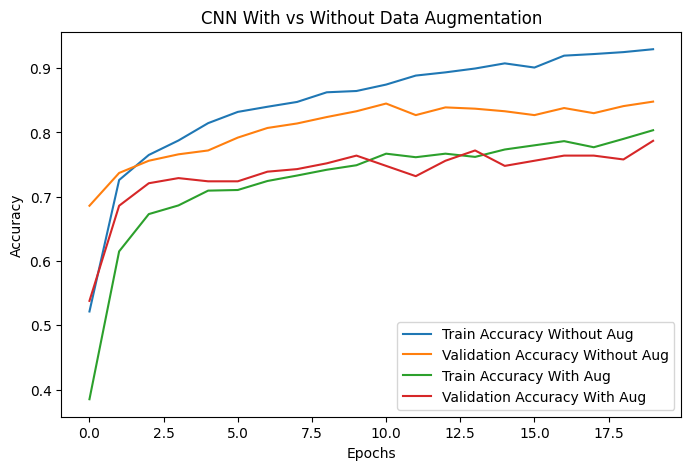

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_without_aug.history['accuracy'],
    label='Train Accuracy Without Aug'
)

plt.plot(
    history_without_aug.history['val_accuracy'],
    label='Validation Accuracy Without Aug'
)

plt.plot(
    history_with_aug.history['accuracy'],
    label='Train Accuracy With Aug'
)

plt.plot(
    history_with_aug.history['val_accuracy'],
    label='Validation Accuracy With Aug'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN With vs Without Data Augmentation")

plt.legend()
plt.show()

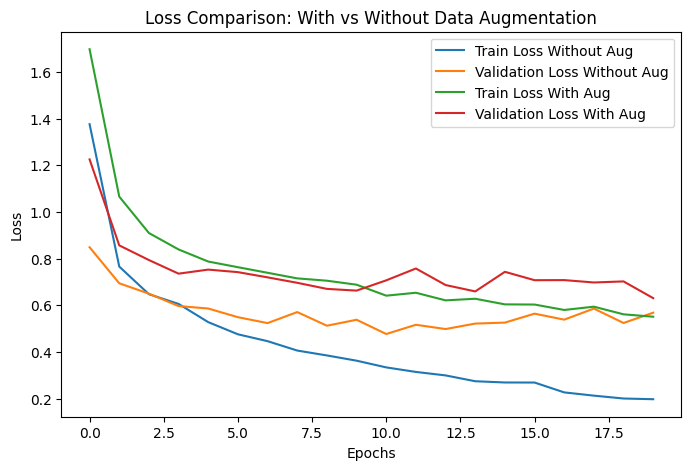

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_without_aug.history['loss'],
    label='Train Loss Without Aug'
)

plt.plot(
    history_without_aug.history['val_loss'],
    label='Validation Loss Without Aug'
)

plt.plot(
    history_with_aug.history['loss'],
    label='Train Loss With Aug'
)

plt.plot(
    history_with_aug.history['val_loss'],
    label='Validation Loss With Aug'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison: With vs Without Data Augmentation")

plt.legend()
plt.show()